# EDA — Post Cleaning
Analisi esplorativa del dataset pulito `data/cleaned/flight_data_2024_cleaned.csv`.
Obiettivo: verificare l'efficacia della pulizia e confrontare i risultati con il dataset grezzo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# ─── Working directory → root del progetto ───────────────────────────────────
while not (Path.cwd() / "data" / "raw").exists():
    os.chdir("..")

RAW_PATH     = Path("data/raw/flight_data_2024.csv")
CLEANED_PATH = Path("data/cleaned/flight_data_2024_cleaned.csv")
os.makedirs("eda/plots", exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

print(f"Working directory: {Path.cwd()}")

# ─── Caricamento ─────────────────────────────────────────────────────────────
raw = pd.read_csv(RAW_PATH, low_memory=False)
df  = pd.read_csv(CLEANED_PATH, low_memory=False)

print(f"Raw shape:     {raw.shape}")
print(f"Cleaned shape: {df.shape}")
df.head(3)

Working directory: /Users/diego/Documents/GitHub/Hadoop-Hive-Spark-FlightsDelay
Raw shape:     (7079081, 35)
Cleaned shape: (7038851, 15)


,fl_date,year,month,op_unique_carrier,origin,dest,dep_delay,arr_delay,cancelled,cancellation_code,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024-01-01,2024,1,9E,JFK,DTW,-5.0,-19.0,0,NaN,0,0,0,0,0
1,2024-01-01,2024,1,9E,MSP,CLE,-14.0,-30.0,0,NaN,0,0,0,0,0
2,2024-01-01,2024,1,9E,JFK,RIC,-4.0,-20.0,0,NaN,0,0,0,0,0


## 1. Confronto Before / After

In [2]:
summary = pd.DataFrame({
    'Raw': [raw.shape[0], raw.shape[1], raw.duplicated().sum(),
            raw['dep_delay'].isnull().sum(), raw['cancelled'].sum()],
    'Cleaned': [df.shape[0], df.shape[1], df.duplicated().sum(),
                df['dep_delay'].isnull().sum(), df['cancelled'].sum()]
}, index=['Righe', 'Colonne', 'Duplicati', 'dep_delay NaN', 'Voli Cancellati'])
print(summary.to_string())

                     Raw  Cleaned
Righe            7079081  7038851
Colonne               35       15
Duplicati              0        0
dep_delay NaN      92970    73164
Voli Cancellati    96315    76503


## 2. Valori Nulli Post-Cleaning

In [3]:
null_df = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('null_pct', ascending=False)
print(null_df.to_string())
print('\nNota: dep_delay/arr_delay NaN = voli cancellati (semanticamente corretti)')
print('Nota: cancellation_code NaN = voli non cancellati (semanticamente corretti)')

                     null_count  null_pct
cancellation_code       6962348     98.91
arr_delay                 93986      1.34
dep_delay                 73164      1.04
fl_date                       0      0.00
year                          0      0.00
month                         0      0.00
op_unique_carrier             0      0.00
origin                        0      0.00
dest                          0      0.00
cancelled                     0      0.00
carrier_delay                 0      0.00
weather_delay                 0      0.00
nas_delay                     0      0.00
security_delay                0      0.00
late_aircraft_delay           0      0.00

Nota: dep_delay/arr_delay NaN = voli cancellati (semanticamente corretti)
Nota: cancellation_code NaN = voli non cancellati (semanticamente corretti)


## 3. Distribuzione Voli per Mese (Confronto)

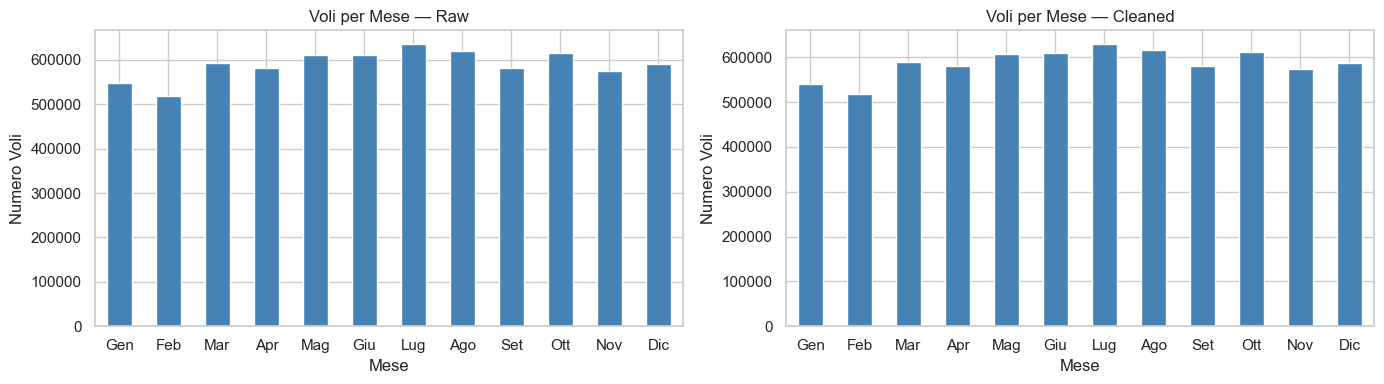

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
mesi = ['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic']
for ax, data, title in zip(axes, [raw, df], ['Raw', 'Cleaned']):
    data['month'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Voli per Mese — {title}')
    ax.set_xlabel('Mese')
    ax.set_ylabel('Numero Voli')
    ax.set_xticklabels(mesi, rotation=0)
plt.tight_layout()
plt.savefig('eda/plots/post_vs_pre_flights_per_month.png', dpi=150)
plt.show()

## 4. Distribuzione Ritardi Post-Cleaning

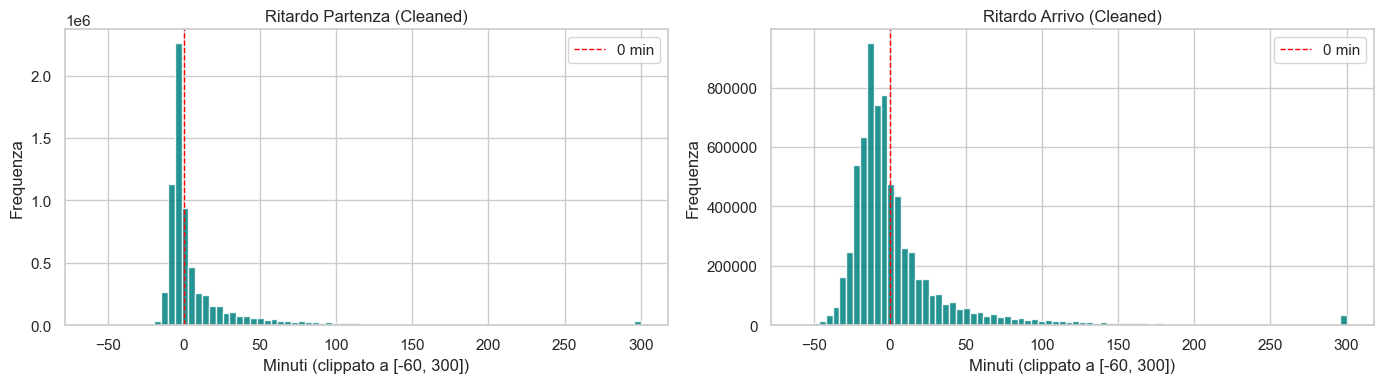

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes, ['dep_delay', 'arr_delay'], ['Ritardo Partenza', 'Ritardo Arrivo']):
    data = df[col].dropna().clip(-60, 300)
    ax.hist(data, bins=80, color='teal', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1, label='0 min')
    ax.set_xlabel('Minuti (clippato a [-60, 300])')
    ax.set_ylabel('Frequenza')
    ax.set_title(f'{title} (Cleaned)')
    ax.legend()
plt.tight_layout()
plt.savefig('eda/plots/post_delay_distribution.png', dpi=150)
plt.show()

## 5. Confronto Statistiche Ritardi Before / After

In [6]:
for col in ['dep_delay', 'arr_delay']:
    print(f'\n── {col} ──')
    comp = pd.DataFrame({
        'Raw':     raw[col].describe(),
        'Cleaned': df[col].describe()
    }).round(2)
    print(comp.to_string())


── dep_delay ──
              Raw     Cleaned
count  6986111.00  6965687.00
mean        12.68       12.58
std         56.06       53.70
min        -96.00      -96.00
25%         -6.00       -6.00
50%         -2.00       -2.00
75%          9.00        9.00
max       3777.00     1439.00

── arr_delay ──
              Raw     Cleaned
count  6965267.00  6944865.00
mean         7.10        7.01
std         57.99       55.72
min       -126.00     -117.00
25%        -15.00      -15.00
50%         -6.00       -6.00
75%          9.00        9.00
max       3803.00     1439.00


## 6. Tasso di Cancellazione per Compagnia

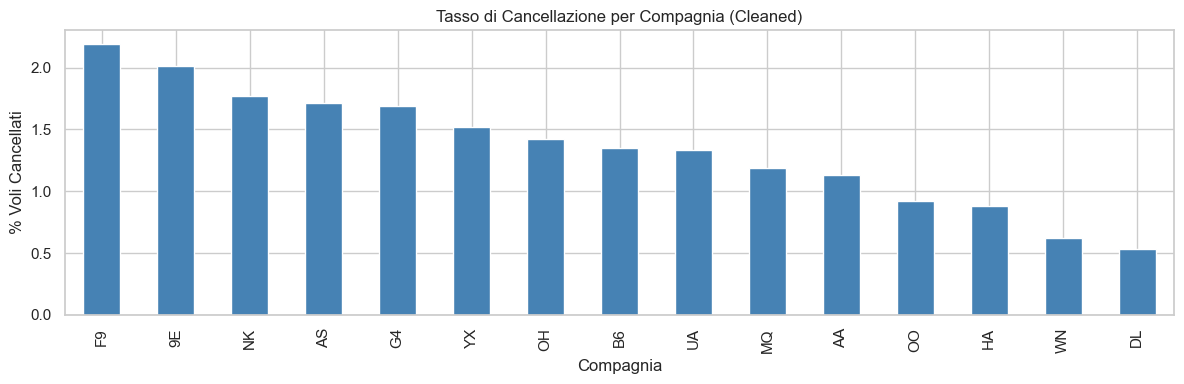

In [7]:
cancel_rate = df.groupby('op_unique_carrier')['cancelled'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(12, 4))
cancel_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Tasso di Cancellazione per Compagnia (Cleaned)')
ax.set_xlabel('Compagnia')
ax.set_ylabel('% Voli Cancellati')
plt.tight_layout()
plt.savefig('eda/plots/post_cancellation_rate_by_carrier.png', dpi=150)
plt.show()

## 7. Ritardo Medio per Compagnia

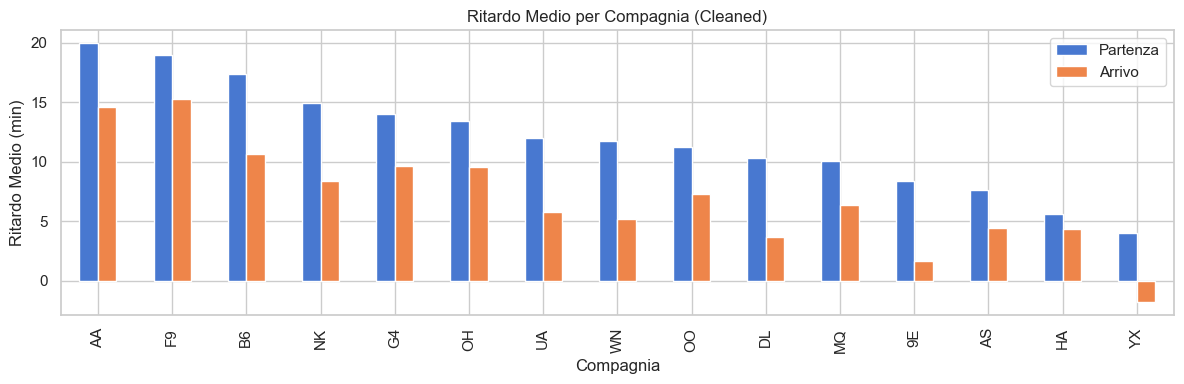

In [8]:
avg_delay = df.groupby('op_unique_carrier')[['dep_delay', 'arr_delay']].mean().round(2).sort_values('dep_delay', ascending=False)
fig, ax = plt.subplots(figsize=(12, 4))
avg_delay.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Ritardo Medio per Compagnia (Cleaned)')
ax.set_xlabel('Compagnia')
ax.set_ylabel('Ritardo Medio (min)')
ax.legend(['Partenza', 'Arrivo'])
plt.tight_layout()
plt.savefig('eda/plots/post_avg_delay_by_carrier.png', dpi=150)
plt.show()

## 8. Ritardo Medio per Mese

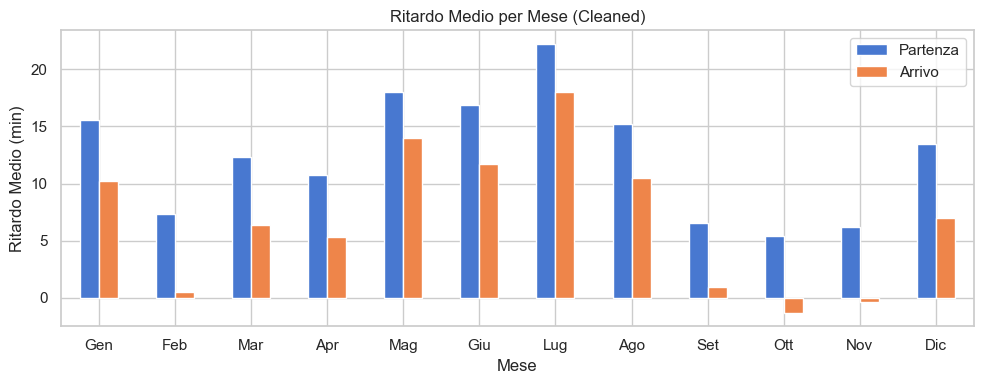

In [9]:
mesi = ['Gen','Feb','Mar','Apr','Mag','Giu','Lug','Ago','Set','Ott','Nov','Dic']
avg_month = df.groupby('month')[['dep_delay', 'arr_delay']].mean().round(2)
fig, ax = plt.subplots(figsize=(10, 4))
avg_month.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Ritardo Medio per Mese (Cleaned)')
ax.set_xlabel('Mese')
ax.set_ylabel('Ritardo Medio (min)')
ax.set_xticklabels(mesi, rotation=0)
ax.legend(['Partenza', 'Arrivo'])
plt.tight_layout()
plt.savefig('eda/plots/post_avg_delay_by_month.png', dpi=150)
plt.show()

## 9. Distribuzione Cause di Cancellazione

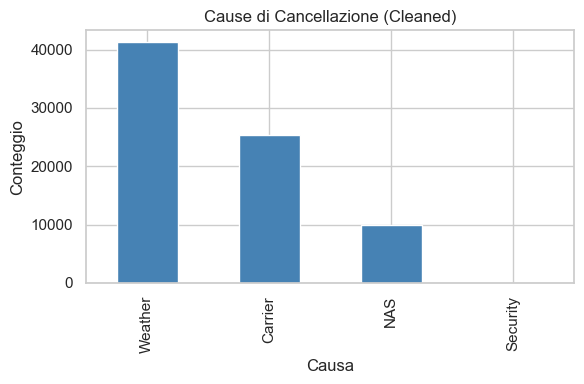

In [10]:
labels = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
cc = df['cancellation_code'].dropna().map(labels).value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
cc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Cause di Cancellazione (Cleaned)')
ax.set_xlabel('Causa')
ax.set_ylabel('Conteggio')
plt.tight_layout()
plt.savefig('eda/plots/post_cancellation_causes.png', dpi=150)
plt.show()

## 10. Top 20 Aeroporti per Ritardo Medio in Partenza

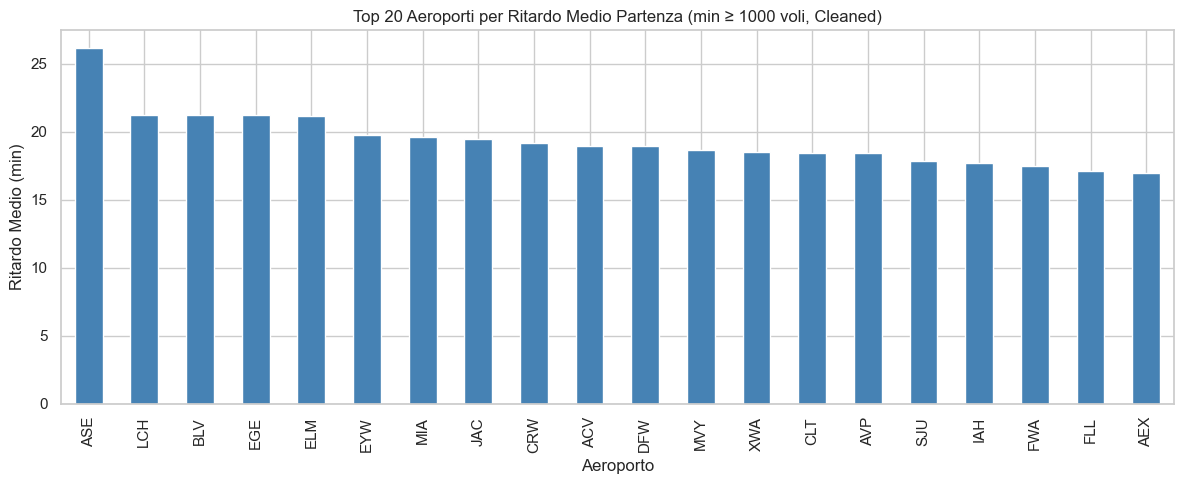

In [11]:
top_airports = (
    df.groupby('origin')['dep_delay']
    .agg(['mean', 'count'])
    .query('count >= 1000')
    .sort_values('mean', ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(12, 5))
top_airports['mean'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Aeroporti per Ritardo Medio Partenza (min ≥ 1000 voli, Cleaned)')
ax.set_xlabel('Aeroporto')
ax.set_ylabel('Ritardo Medio (min)')
plt.tight_layout()
plt.savefig('eda/plots/post_top20_airports_delay.png', dpi=150)
plt.show()

## 11. Statistiche Descrittive Finali

In [12]:
df[['dep_delay', 'arr_delay', 'carrier_delay', 'weather_delay',
    'nas_delay', 'security_delay', 'late_aircraft_delay']].describe().round(2)

,dep_delay,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,6965687.00,6944865.00,7038851.00,7038851.00,7038851.00,7038851.00,7038851.00
mean,12.58,7.01,4.99,0.87,2.79,0.03,5.93
std,53.70,55.72,33.28,15.20,15.41,1.43,30.21
min,-96.00,-117.00,0.00,0.00,0.00,0.00,0.00
25%,-6.00,-15.00,0.00,0.00,0.00,0.00,0.00
50%,-2.00,-6.00,0.00,0.00,0.00,0.00,0.00
75%,9.00,9.00,0.00,0.00,0.00,0.00,0.00
max,1439.00,1439.00,1435.00,1423.00,1388.00,1164.00,1414.00
